# Atelier Seaborn

## Contexte 
Une entreprise possède plusieurs bâtiments équipés de capteurs IoT. 
Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression, 
la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure. 
Après avoir utilisé NumPy pour manipuler les données numériques, Pandas pour importer, nettoyer 
et analyser le dataset et Matplotlib pour réaliser des visualisations, l'étape suivante consiste à se 
servir de Seaborn pour réaliser une analyse exploratoire plus riche des données. 

## Structure du projet 

### 1) Structurer le projet comme suit : 
atelier_seaborn_iot/ 
│ 
├── data/ 
│   
└── mesures_capteurs.csv 
│    
├── notebooks/ 
│   
└── atelier_seaborn_iot.ipynb
│ 
└── exports/ 
├── temperature.png 
├── temperature.pdf  
└── ... 

### 2) Stocker le fichier fourni mesures_capteurs.csv dans le sous-dossier data 
### 3) Créer le notebook atelier_seaborn_iot.ipynb 

In [1]:
%pip install ipykernel

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Creation du fichier notebook dans le dossier notebooks
# %mkdir atelier_seaborn_iot.ipynb

### 4) Installer et importer seaborn, matplotlib, pandas, numpy 

In [3]:
# Installation (si besoin, décommenter)
# !pip install pandas numpy matplotlib seaborn

#%pip install numpy pandas matplotlib seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", rc={"figure.figsize": (10, 6)})
%matplotlib inline

**style="whitegrid"** définit l'apparence (fond blanc, grille légère, couleurs par défaut, etc.).

**rc** (pour "runtime configuration") permet de passer des réglages supplémentaires à matplotlib via seaborn. "figure.figsize": (10, 6) fixe la taille par défaut de chaque figure à 10 (largeur) sur 6 (hauteur), en pouces.

### 5) Importer mesures_capteurs.csv dans le dataframe df 

**Pour importer le fichier csv dans le dataframe df il faut:**
Charge le CSV dans un DataFrame pandas (tableau exploitable). Le ../ remonte d'un dossier depuis notebooks/ pour aller chercher data/.

In [4]:
df = pd.read_csv("../data/mesures_capteurs.csv")
#df.head() affiche les 5 premières lignes, pour vérifier que l'import est correct.
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


### 6) Vérifier le contenu du dataframe df 

In [5]:
#df.info() Structure du tableau : colonnes, types, valeurs non-nulles par colonne.
df.info()
print("_________________________________________________________________________________")
#df.isna().sum() Nombre de valeurs manquantes par colonne.
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB
_________________________________________________________________________________


id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     6
humidite        5
pression        5
consommation    5
etat            4
dtype: int64

In [6]:
#df.describe() Statistiques des colonnes numériques : moyenne, min, max, quartiles.
df.describe()

,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


## Partie 1 – Distribution d'une variable avec histplot()

**Objectif :** Visualiser comment les valeurs de température se répartissent : autour de quelle valeur elles sont concentrées, si la distribution est symétrique, et s'il y a des valeurs extrêmes.

### 1) Afficher la distribution des températures

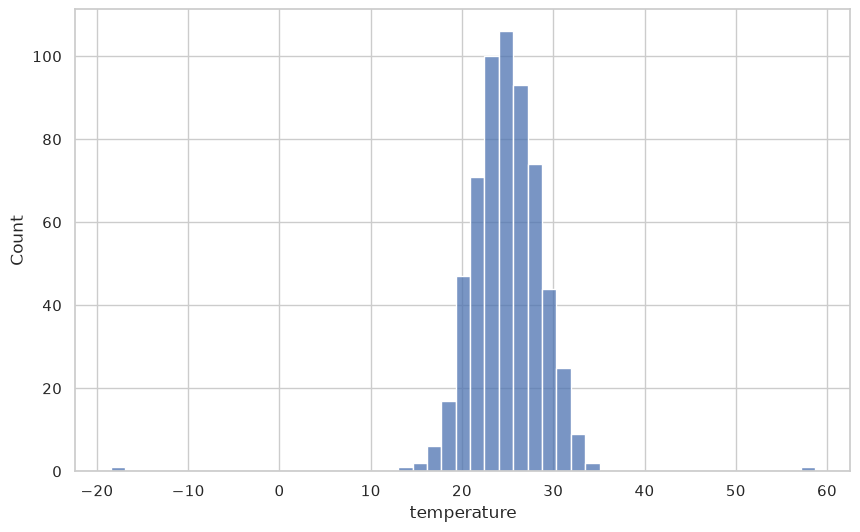

In [7]:
sns.histplot(data=df, x="temperature")
plt.show()

**data=df :** le DataFrame source

**x="temperature" :** la colonne à analyser

Seaborn découpe automatiquement les valeurs en "classes" (bins) et affiche une barre par classe, dont la hauteur correspond au nombre de mesures dans cette classe

### 2) Autour de quelle valeur les températures sont concentrées ?

In [8]:
print(df["temperature"].mean())
print(df["temperature"].median())

24.87831385642738
24.86


Les températures se concentrent principalement entre 20 et 30 °C, avec une moyenne de 24,88 °C et une médiane de 24,86 °C. 

Ces deux valeurs étant très proches, cela confirme que le pic de la distribution se situe bien autour de 25 °C.

###  3) La distribution semble-t-elle symétrique ? 

La distribution semble légèrement asymétrique : la majorité des températures sont concentrées autour de 25 °C, mais on observe quelques valeurs très faibles qui s'écartent nettement de ce groupe principal, avec très peu d'observations dans cette zone. 

Cela crée une traîne (queue) vers la gauche , ce qui rend la distribution non parfaitement symétrique.

In [9]:
df["temperature"].skew()

np.float64(-1.0470722374889554)

Le résultat est négatif, ça confirme une asymétrie vers la gauche comme on l'as observé.

### 4) Existe-t-il des valeurs extrêmes ? 

In [10]:
Q1 = df["temperature"].quantile(0.25)
Q3 = df["temperature"].quantile(0.75)
IQR = Q3 - Q1

borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

outliers = df[(df["temperature"] < borne_basse) | (df["temperature"] > borne_haute)]
print(f"Bornes : [{borne_basse:.2f}, {borne_haute:.2f}]")
print(f"Nombre de valeurs extrêmes : {len(outliers)}")
outliers

Bornes : [15.51, 34.33]
Nombre de valeurs extrêmes : 5


,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
43,M0575,2026-01-28 22:00:00,C011,B004,34.72,57.50,1008.94,266.22,ALERTE
245,M0127,2026-01-10 06:00:00,C007,B003,14.11,145.00,1032.36,169.57,ERREUR
258,M0223,2026-01-14 06:00:00,C007,B003,15.49,47.96,1006.34,124.90,OK
487,M0538,2026-01-27 09:00:00,C010,B004,-18.50,66.27,1012.49,312.92,ERREUR
502,M0048,2026-01-06 23:00:00,C012,B004,58.70,81.51,1026.79,271.92,ERREUR


**Sur les 5 valeurs extrêmes détectées :**

4 sur 5 sont associées à un état anormal du capteur (ALERTE ou ERREUR), ce qui suggère que ces températures extrêmes ne sont pas de simples variations naturelles, mais plutôt des dysfonctionnements de capteurs.

On trouve à la fois des valeurs anormalement basses (-18,50 °C, 14,11 °C) et anormalement hautes (58,70 °C, 34,72 °C) — ce qui explique pourquoi la distribution a une traîne des deux côtés, mais surtout vers la gauche comme vu avec le skewness.

Ces valeurs se concentrent surtout sur les bâtiments B003 et B004, notamment via les capteurs C007, C010, C011, C012.

Un seul outlier (15,49 °C) est marqué OK, ce qui suggère qu'il s'agit peut-être d'une vraie mesure basse plutôt que d'une anomalie technique.

### 5) Modifier le nombre de classes 

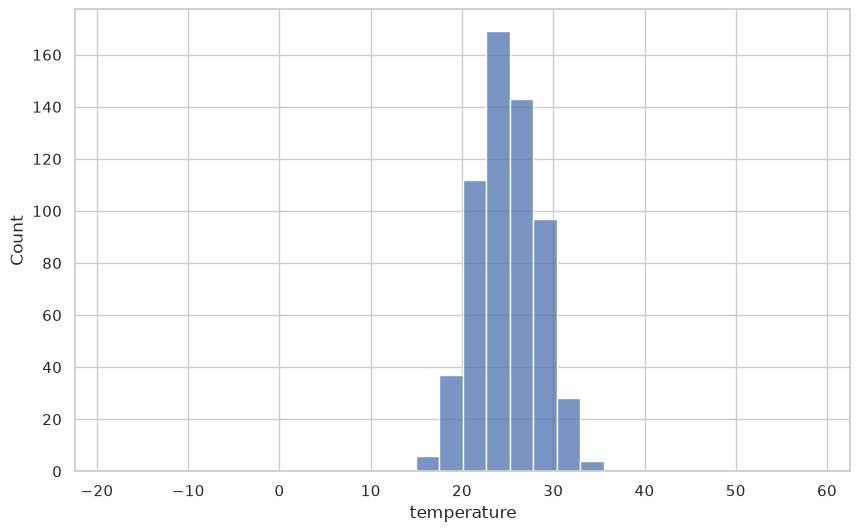

In [11]:
sns.histplot(data=df, x="temperature", bins=30)
plt.show()

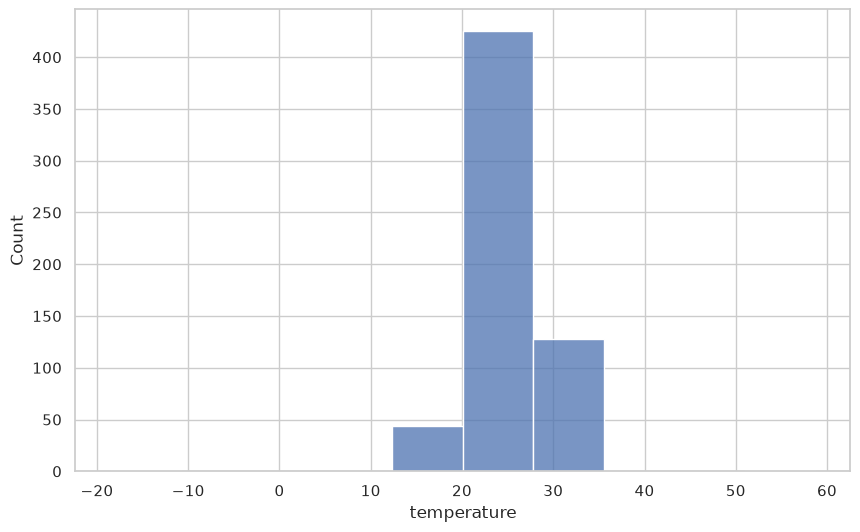

In [12]:
sns.histplot(data=df, x="temperature", bins=10)
plt.show()

Avec 10 bins, l'histogramme est très lissé : on ne distingue plus que 3 grandes barres, ce qui masque les détails de la distribution (les valeurs extrêmes en particulier disparaissent visuellement, noyées dans les classes larges).

Avec 30 bins, on obtient 8 barres visibles, ce qui donne plus de détail sur la forme de la distribution — mais les petites barres correspondant aux valeurs extrêmes (visibles dans l'histogramme par défaut) ne sont plus visibles non plus.

### 6) Afficher la distribution des températures par bâtiment

**hue** sert à découper les données par catégorie en utilisant une couleur différente pour chaque groupe.

**multiple="stack"** Ce paramètre contrôle comment les 4 distributions sont affichées les unes par rapport aux autres, une fois qu'on a déjà utilisé hue.

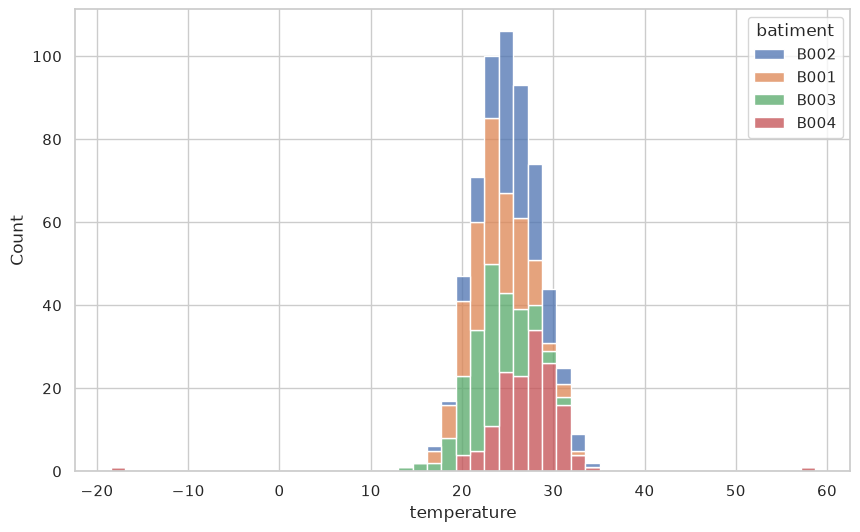

In [13]:
sns.histplot(data=df, x="temperature", hue="batiment", multiple="stack")
plt.show()

## Partie 2 – Distribution d'une variable avec kdeplot() 

### 1) Afficher la distribution des températures 

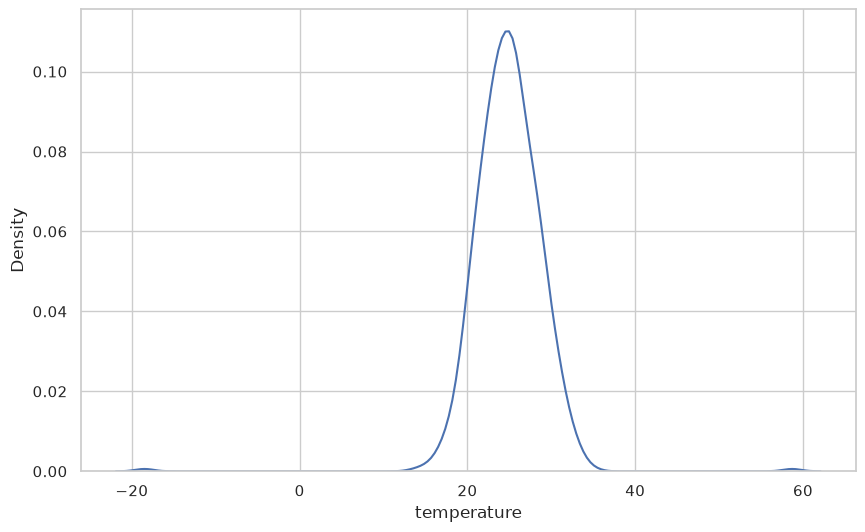

In [14]:
sns.kdeplot(data=df, x="temperature")
plt.show()

**Objectif:** Comme **histplot(), kdeplot()** montre la distribution d'une variable — mais au lieu de barres, il trace une courbe lissée qui estime la densité de probabilité. 

C'est utile pour voir la forme générale de la distribution sans dépendre du choix de bins.

**kdeplot** calcule une estimation de densité **(KDE = Kernel Density Estimation)** : au lieu de compter les valeurs par tranche comme l'histogramme, il "lisse" chaque point de donnée pour obtenir une courbe continue. 

Le résultat ressemble à un histogramme dont on aurait arrondi les contours, plus facile pour juger la forme générale (symétrie, nombre de pics) sans le bruit lié au choix des bins.

### 2) Afficher la distribution des températures par bâtiment

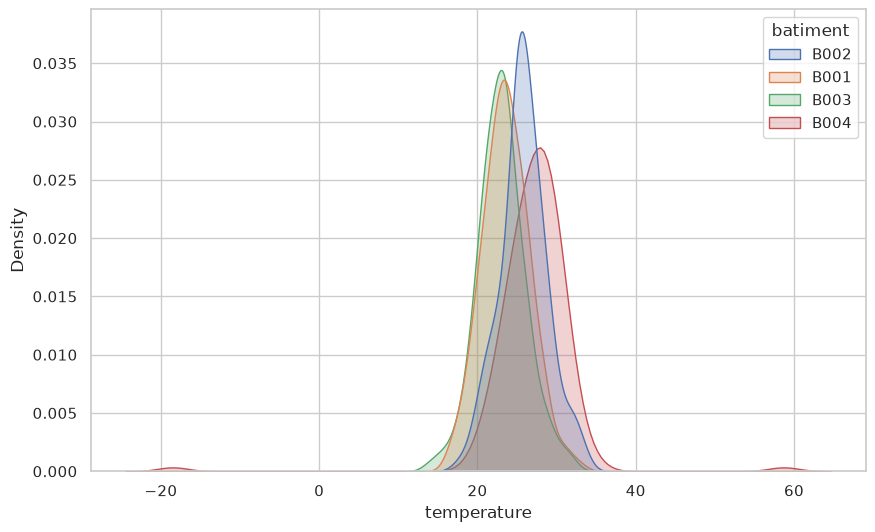

In [15]:
sns.kdeplot(data=df, x="temperature", hue="batiment", fill="True")
plt.show()

**Explication :** Même logique que pour histplot() — hue="batiment" trace une courbe par bâtiment, chacune dans sa couleur, ce qui permet de comparer directement la forme et la position des distributions entre bâtiments.

**Sans fill=True :** seaborn trace uniquement le contour de la courbe (une ligne), une couleur par bâtiment, sans remplissage.

**Avec fill=True :** seaborn remplit l'espace sous la courbe avec la couleur, et applique automatiquement une transparence (un peu comme alpha=0.5 effectivement) pour que les zones où plusieurs courbes se chevauchent restent lisibles — sinon une couleur opaque cacherait complètement les autres en dessous.

## Partie 3 – Distribution d'une variable avec boxplot() 

### 1) Afficher la distribution des températures 

**Objectif :** Le boxplot ("boîte à moustaches") résume une distribution avec quelques repères statistiques clés : médiane, quartiles, dispersion, valeurs extrêmes. Contrairement à histplot() et kdeplot(), il ne montre pas la forme détaillée de la distribution, mais donne une lecture rapide et standardisée de sa structure.

**Comment lire un boxplot :**

La boîte va du 1er quartile (Q1, 25%) au 3e quartile (Q3, 75%) → elle contient 50% des données

La ligne au milieu de la boîte = la médiane

Les moustaches (traits qui dépassent de la boîte) s'étendent jusqu'aux valeurs les plus extrêmes qui restent dans la plage [Q1 - 1,5×IQR, Q3 + 1,5×IQR]

Les points isolés au-delà des moustaches = les valeurs extrêmes (outliers)

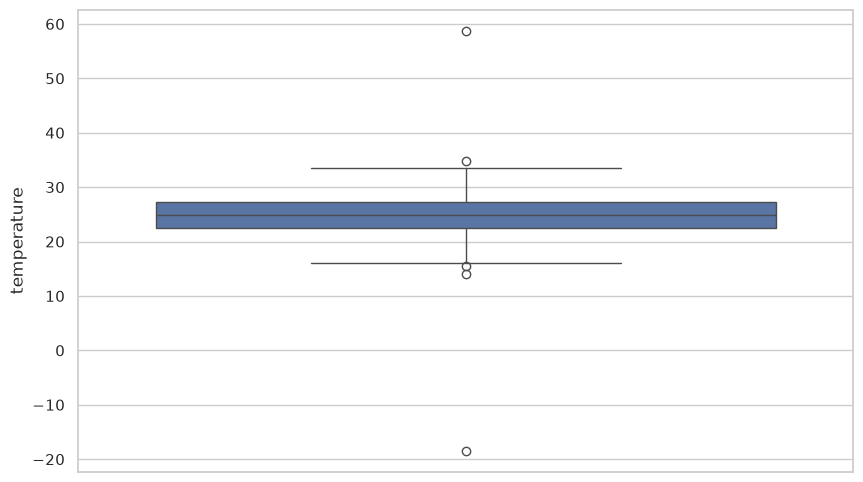

In [16]:
sns.boxplot(data=df, y="temperature")
plt.show()

**Explication :** y="temperature" (plutôt que x) trace la boîte verticalement, ce qui est la convention la plus lisible pour un seul boxplot.

### 2) Afficher la distribution des températures par bâtiment 

**Objectif :** Comparer visuellement la distribution des températures entre les 4 bâtiments, en utilisant un boxplot par bâtiment placé côte à côte.

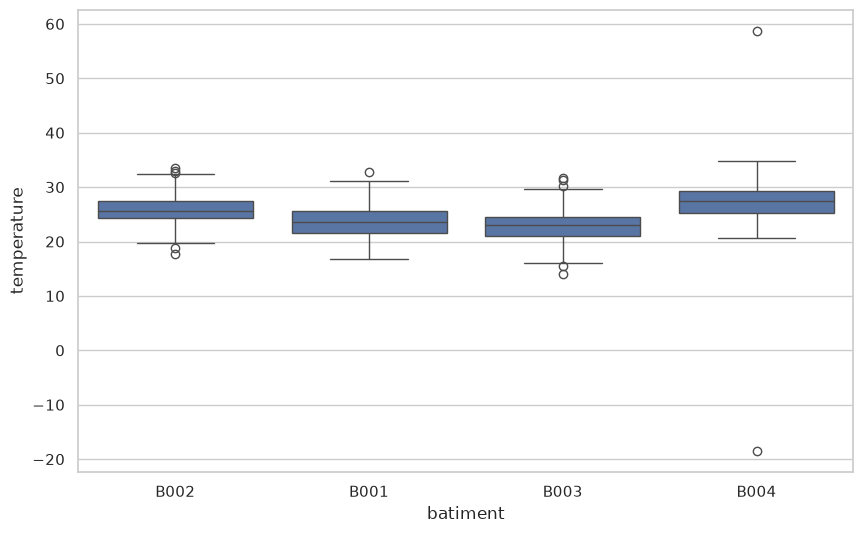

In [17]:
sns.boxplot(data=df, x="batiment", y="temperature")
plt.show()

**Ce que ça fait :**

x="batiment"  seaborn regroupe les données par bâtiment et trace une boîte à moustaches par bâtiment, positionnées côte à côte sur l'axe horizontal
y="temperature"  chaque boîte résume la distribution des températures de ce bâtiment uniquement

### 3) Pour chaque bâtiment, 

#### a) quelle est la médiane ?  

In [18]:
df.groupby("batiment")["temperature"].median()

batiment
B001    23.540
B002    25.670
B003    23.045
B004    27.535
Name: temperature, dtype: float64

Les médianes varient modérément d'un bâtiment à l'autre : de 23,05 °C (B003) à 27,54 °C (B004), avec B001 et B002 entre les deux (23,54 °C et 25,67 °C). Aucun bâtiment n'est donc radicalement plus froid ou plus chaud que les autres, les écarts restent raisonnables (~4,5 °C d'amplitude).

#### b) quelle est la dispersion ?  

In [19]:
df.groupby("batiment")["temperature"].agg(["std", "min", "max"])

,std,min,max
batiment,,,
B001,2.961211,16.77,32.72
B002,2.951828,17.67,33.60
B003,2.983902,14.11,31.74
B004,5.367361,-18.50,58.70


B001, B002 et B003 ont une dispersion très homogène (écart-type autour de 3). B004 se distingue nettement avec un écart-type de 5,37, presque le double des autres — confirmé par ses valeurs extrêmes (-18,50 °C à 58,70 °C). B004 est donc le bâtiment le moins stable en température.

#### c) les valeurs extrêmes 

In [20]:
for batiment, groupe in df.groupby("batiment"):
    Q1 = groupe["temperature"].quantile(0.25)
    Q3 = groupe["temperature"].quantile(0.75)
    IQR = Q3 - Q1
    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR
    outliers = groupe[(groupe["temperature"] < borne_basse) | (groupe["temperature"] > borne_haute)]
    print(f"{batiment} : bornes [{borne_basse:.2f}, {borne_haute:.2f}] — {len(outliers)} outlier(s)")
    print(outliers[["temperature"]].values.flatten())

B001 : bornes [15.52, 31.76] — 1 outlier(s)
[32.72]
B002 : bornes [19.37, 32.42] — 5 outlier(s)
[32.9  33.6  18.85 32.56 17.67]
B003 : bornes [15.81, 29.86] — 5 outlier(s)
[31.74 30.16 14.11 15.49 31.3 ]
B004 : bornes [19.01, 35.44] — 2 outlier(s)
[-18.5  58.7]


Bien que B002 et B003 comptent chacun 5 outliers (le plus grand nombre), leurs valeurs extrêmes restent proches des bornes normales (par exemple 32,9 °C ou 14,11 °C). 

B004, en revanche, n'a que 2 outliers, mais ce sont de très loin les plus extrêmes en amplitude : -18,50 °C et 58,70 °C, des valeurs physiquement aberrantes pour un bâtiment, liées à des capteurs défaillants (état ERREUR).

**Conclusion :** en nombre, B002 et B003 ont le plus d'outliers ; mais en gravité, B004 reste le bâtiment le plus problématique, avec des écarts extrêmes qui traduisent clairement des dysfonctionnements de capteurs plutôt que de simples variations naturelles de température.

### 4) quels bâtiments ont les valeurs les plus extrêmes ?

C'est B004 qui a les valeurs les plus extrêmes, malgré un nombre d'outliers plus faible (2 contre 5 pour B002 et B003) : ses valeurs atteignent -18,50 °C et 58,70 °C, des écarts physiquement aberrants liés à des capteurs en état ERREUR, alors que les outliers de B002 et B003 restent proches des bornes normales.

## Partie 4 – Distribution d'une variable avec violinplot()

**Objectif :** Le violin plot combine les avantages du boxplot (médiane, quartiles) et du KDE (forme de la distribution). Il permet de voir en un seul graphique à la fois les statistiques résumées et la forme complète de la distribution.

Comment lire un violin plot :

La largeur du "violon" à une hauteur donnée = la densité de données à cette valeur (comme un KDE, mais tracé verticalement et en miroir des deux côtés)

À l'intérieur, on retrouve souvent une mini boîte à moustaches (médiane, quartiles)

### 1) Afficher la distribution des températures 

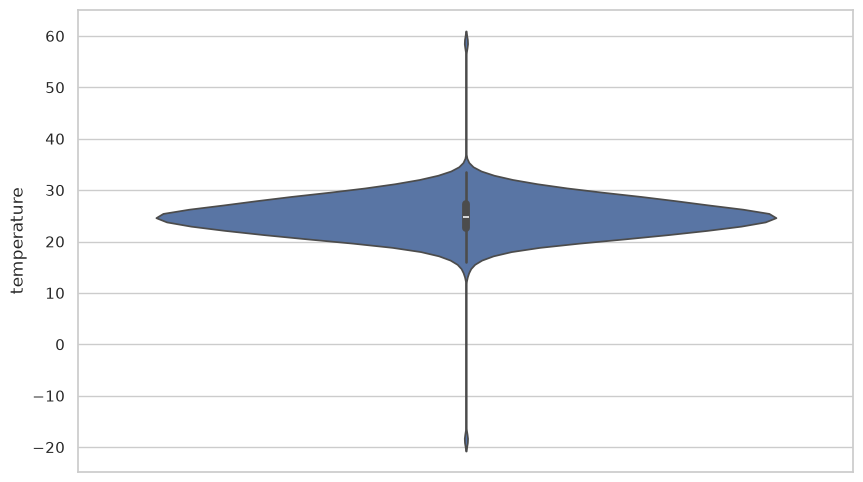

In [21]:
sns.violinplot(data=df, y="temperature")
plt.show()

Les températures restent comprises globalement entre 10 et 40 °C, avec un renflement plus large (donc une concentration plus forte de données) entre 20 et 30 °C, ce qui confirme le pic déjà observé avec l'histogramme et le KDE.

###  2) Afficher la distribution des températures par bâtiment

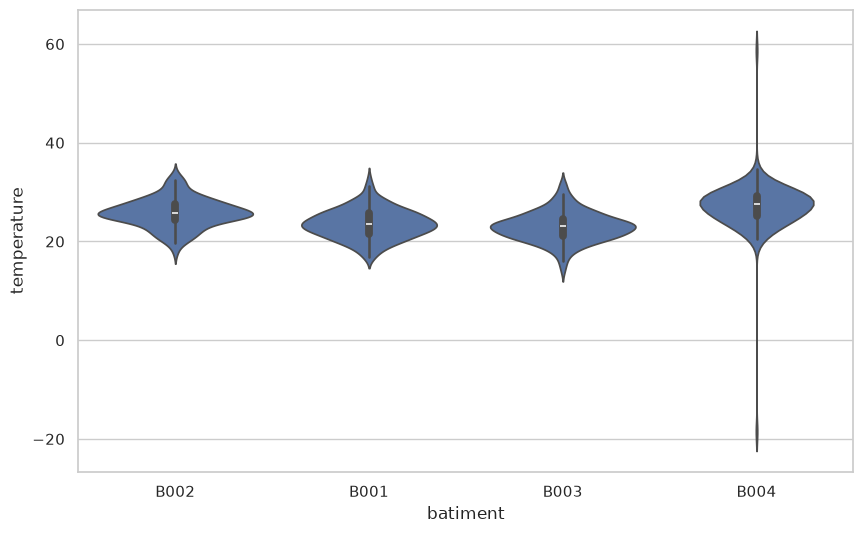

In [22]:
sns.violinplot(data=df, x="batiment", y="temperature")
plt.show()

Les violons des 4 bâtiments ont une taille globalement similaire, ce qui confirme la dispersion homogène déjà vue avec le boxplot (B001, B002, B003). 

En revanche, le violon de B004 se distingue par une queue beaucoup plus longue et fine, qui s'étend bien au-delà des autres, au point de sortir de l'échelle d'affichage commune aux autres bâtiments. 

Ça illustre bien la présence des valeurs extrêmes déjà identifiées (-18,50 °C et 58,70 °C).

###  3) Quelles informations supplémentaires le violin plot permet-il de visualiser par rapport au box plot

Le boxplot résume la distribution avec seulement quelques repères statistiques (médiane, quartiles, moustaches, outliers isolés), mais il ne montre pas la forme réelle de la distribution. 

Deux distributions très différentes (par exemple une avec un seul pic, une autre avec deux pics) peuvent donner exactement le même boxplot.

Le violin plot, lui, ajoute la densité complète de la distribution (comme un KDE) de chaque côté du boxplot. 

**Ça permet de voir en plus :**

où se concentrent réellement les données (les renflements/bosses), pas juste les quartiles

si la distribution est unimodale ou multimodale (un seul pic ou plusieurs pics)

la forme précise de la traîne des valeurs extrêmes (comme la longue queue fine de B004), plutôt que de simples points isolés comme sur le boxplot

**En résumé :** le boxplot donne un résumé statistique compact, le violin plot ajoute la richesse visuelle de la forme de la distribution, un peu comme combiner boxplot + kdeplot en un seul graphique.

## Partie 5 – Comptage des catégories avec countplot()

### 1) Afficher le nombre de mesures par état

**Objectifs :** ici on compte des occurrences de variables catégorielles (état des capteurs, bâtiments). 

**countplot()** affiche une barre par catégorie, dont la hauteur = le nombre de lignes ayant cette valeur.

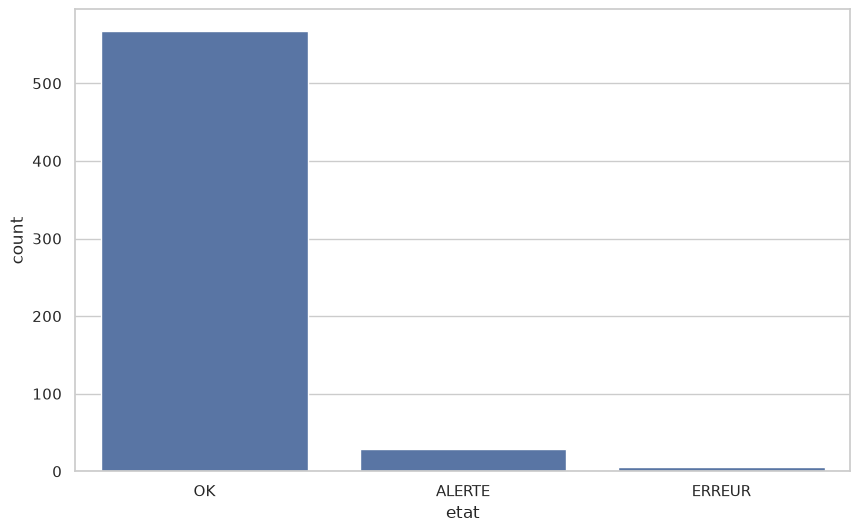

In [23]:
sns.countplot(data=df, x="etat")
plt.show()

**Explication :** x="etat" regroupe les lignes par valeur de la colonne etat (OK, ALERTE, ERREUR) et compte combien de fois chaque valeur apparaît. 

Contrairement à histplot(), il n'y a pas de calcul de densité ou de bins ici — c'est un simple comptage.

### 2) Afficher le nombre de mesures par bâtiment

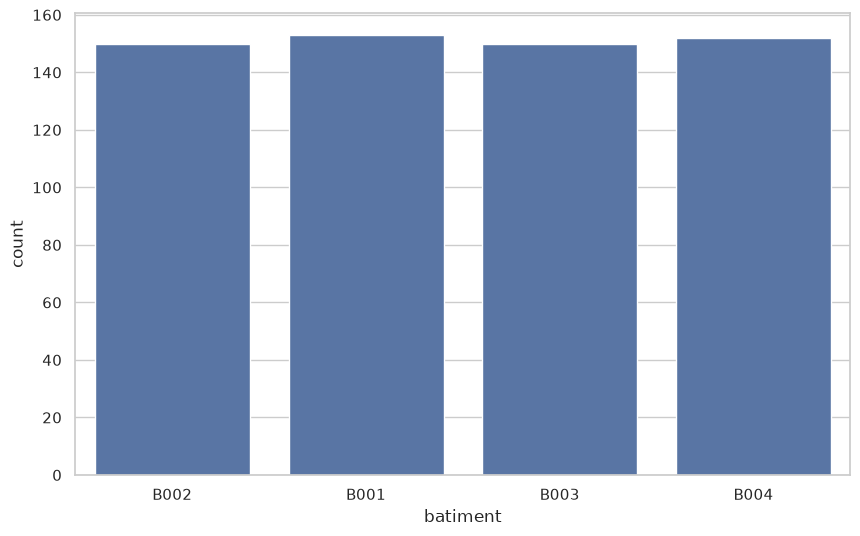

In [24]:
sns.countplot(data=df , x="batiment")
plt.show()

### 3) Afficher les états des capteurs par bâtiment pour identifier  

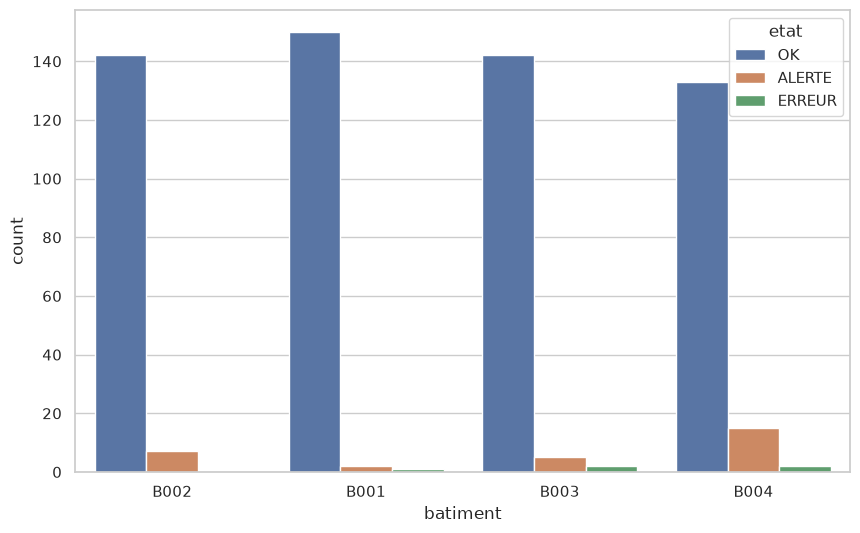

In [25]:
sns.countplot(data=df, x="batiment", hue="etat")
plt.show()

#### a) le bâtiment ayant le plus de mesures en état OK ;

B001 a le plus de mesures en état OK (150), suivi de près par B002 et B003 (142 chacun), tandis que B004 en a le moins (133).

#### b) celui ayant le plus de mesures en ALERTE ;

B004 a nettement le plus de mesures en ALERTE (15, contre 2 à 7 pour les autres bâtiments).

#### c) celui ayant le plus de mesures en ERREUR.

In [26]:
df.groupby(["batiment", "etat"]).size().unstack(fill_value=0)

etat,ALERTE,ERREUR,OK
batiment,,,
B001,2,1,150
B002,7,0,142
B003,5,2,142
B004,15,2,133


Pour les ERREUR, B003 et B004 sont à égalité (2 chacun), B001 en a 1, et B002 n'en a aucun.

## Partie 6 – Relation entre deux variables avec scatterplot()

**Objectif :** Jusqu'ici on étudiait une seule variable à la fois (distribution) ou une variable numérique face à une catégorie (bâtiment). 

Ici, on regarde la relation entre deux variables numériques : température et consommation. 

Chaque point du graphique = une mesure, positionnée selon sa température (x) et sa consommation (y).

 ### 1) Etudier graphiquement la relation entre température et consommation

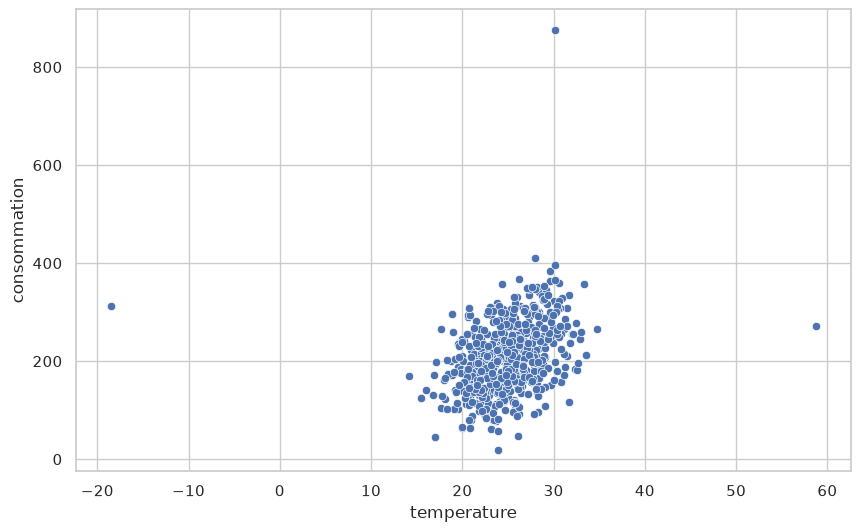

In [27]:
sns.scatterplot(data=df, x="temperature", y="consommation")
plt.show()

**Explication :** x="temperature" et y="consommation" — chaque point représente une mesure unique. Ça permet de voir visuellement si les deux variables évoluent ensemble (tendance croissante/décroissante) ou n'ont pas de lien apparent (nuage de points dispersé sans forme).

### 2) Etudier graphiquement la relation entre température et consommation par bâtiment

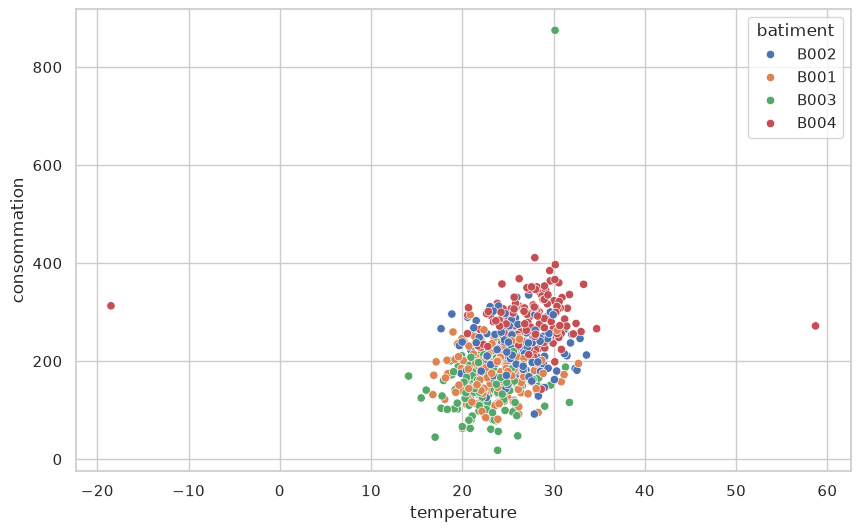

In [28]:
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment")
plt.show()

**Explication :** hue="batiment" colore les points selon le bâtiment, ce qui permet de voir si la relation température/consommation est différente d'un bâtiment à l'autre (une couleur = un bâtiment).

### 3) Modifier la taille des points 

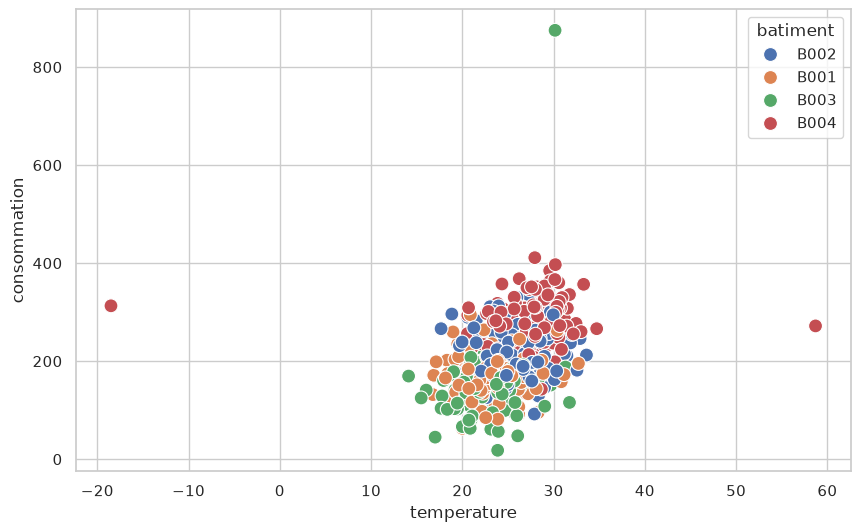

In [29]:
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment", s=100)
plt.show()

**Explication :** s (size) contrôle la taille des points (en points², une unité matplotlib). Par défaut c'est assez petit ; l'augmenter (ex: s=100) rend chaque point plus visible, utile surtout si le nuage de points est peu dense ou pour une meilleure lisibilité en présentation.

## Partie 7 – Régression avec regplot() 

### Etudier graphiquement une tendance entre température et consommation 

**Objectif :** regplot() va plus loin que scatterplot() : en plus d'afficher le nuage de points, il calcule et trace automatiquement une droite de régression linéaire, avec une zone d'incertitude autour. Ça permet de visualiser clairement la tendance (positive, négative, nulle) entre température et consommation.

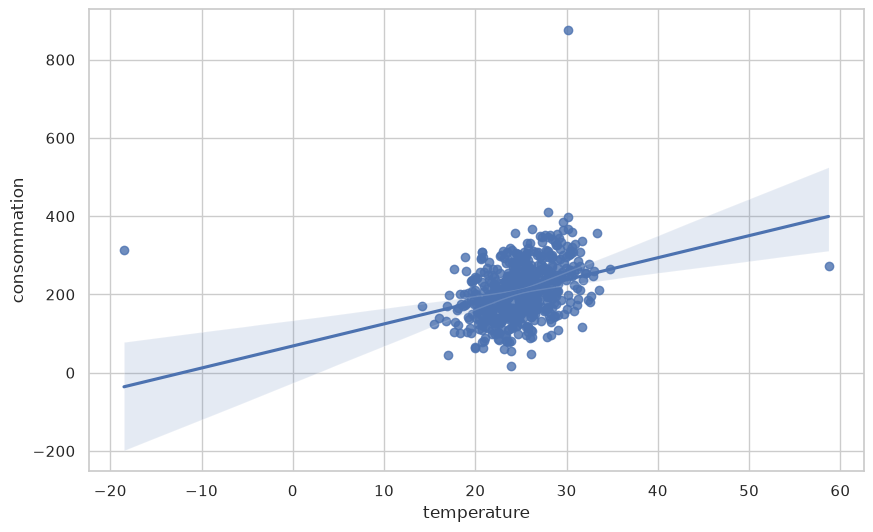

In [30]:
sns.regplot(data=df, x="temperature", y="consommation")
plt.show()

**Explication :**

x="temperature", y="consommation" : mêmes variables qu'en Partie 6
Seaborn calcule une régression linéaire simple (méthode des moindres carrés) sur ces deux variables et trace la droite qui approxime le mieux la relation entre elles

La zone ombrée autour de la droite représente l'intervalle de confiance (à 95% par défaut) de cette estimation — plus elle est étroite, plus la tendance est fiable statistiquement

**Interprétation :**
La droite monte de gauche à droite, ce qui confirme une relation positive entre température et consommation : 

plus la température augmente, plus la consommation énergétique a tendance à augmenter également, probablement lié à l'usage de la climatisation dans les bâtiments.

In [31]:
df["temperature"].corr(df["consommation"])

np.float64(0.31704781604457877)

Le coefficient de corrélation est de +0,32. Il est positif, ce qui confirme la tendance croissante observée visuellement (droite qui monte). 

En revanche, il est modéré (assez éloigné de +1) : ça signifie que la relation entre température et consommation existe bien, mais qu'elle n'est pas très forte, d'autres facteurs que la seule température influencent probablement la consommation (heure de la journée, bâtiment, isolation, usage des équipements, etc.).

## Partie 8 – Régression avec lmplot()

### Etudier graphiquement une tendance entre température et consommation par bâtiment 

**Objectif :** lmplot() fait la même chose que regplot() (nuage de points + droite de régression), mais avec un avantage clé : il permet de séparer automatiquement la régression par catégorie, par exemple par bâtiment, soit sur des sous-graphiques distincts, soit superposées sur un même graphique.

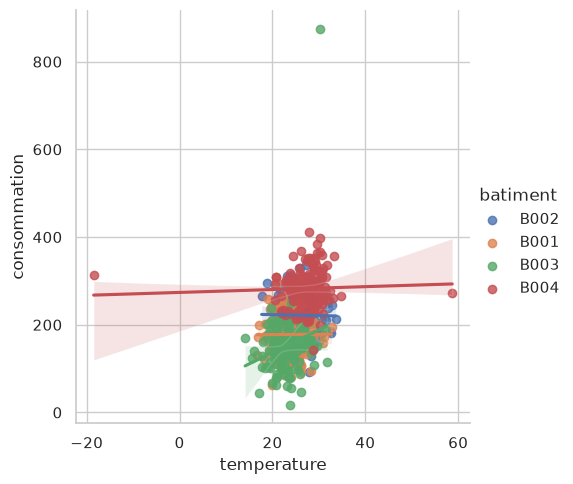

In [32]:
sns.lmplot(data=df, x="temperature", y="consommation", hue="batiment")
plt.show()

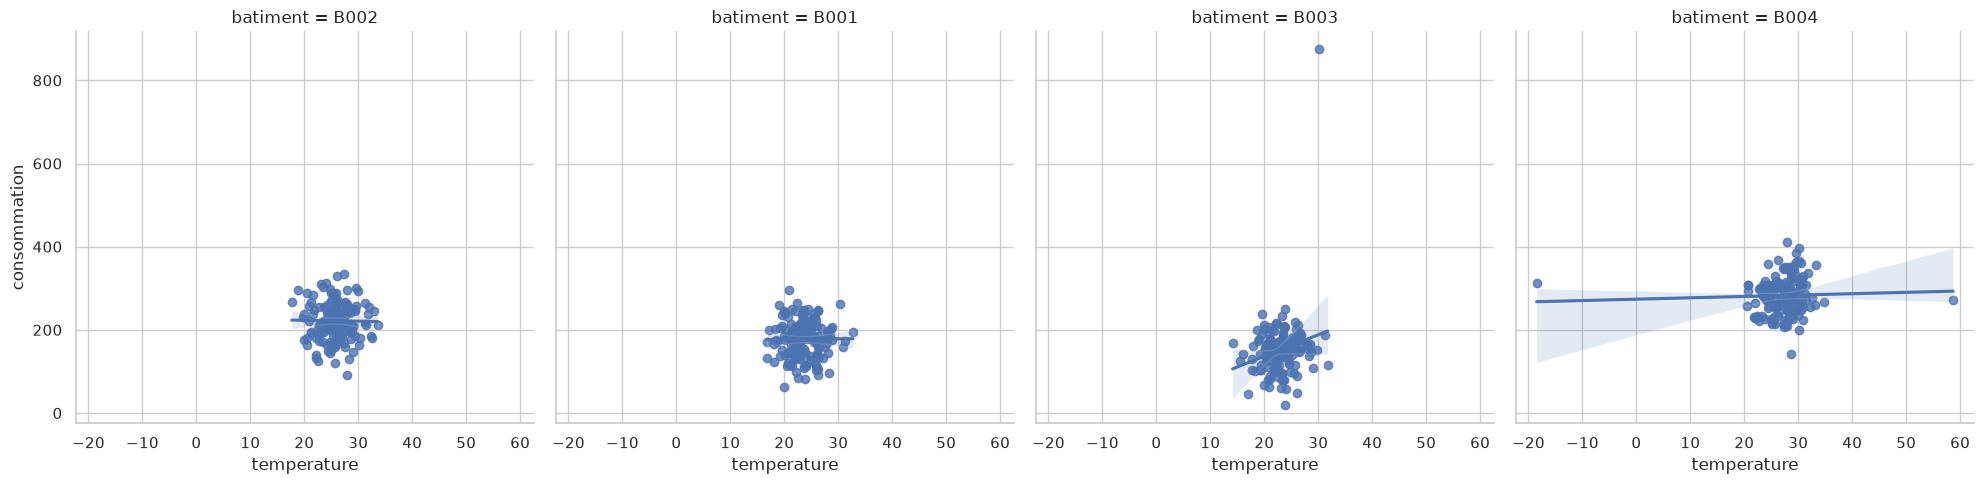

In [33]:
sns.lmplot(data=df, x="temperature", y="consommation", col="batiment")
plt.show()

Sur le graphique superposé (hue="batiment"), les droites de régression sont globalement courtes pour B001, B002 et B003, ce qui reflète simplement que ces bâtiments ont une plage de températures plus restreinte.

La droite de B004 est nettement plus longue, cohérent avec l'étendue beaucoup plus large de ses températures (-18,50 °C à 58,70 °C) déjà observée dans les parties précédentes, mais comme confirmé par le calcul de corrélation, cette longueur reflète surtout l'étendue des valeurs, pas la force de la relation.

Sur les 4 sous-graphiques séparés (col="batiment") :

B003 montre la pente la plus nette visuellement, avec une tendance croissante apparente

B001 et B002 ont des droites presque plates, suggérant une relation température/consommation faible

B004 montre une droite étendue, mais qui reste trompeuse : la relation y est en réalité très faible

**Pour conclure :** les corrélations calculées par bâtiment (B001 : 0,006 ; B002 : -0,014 ; B003 : 0,21 ; B004 : 0,04) sont toutes faibles, y compris pour B003 qui semblait pourtant avoir la pente la plus marquée visuellement. 

La relation température/consommation n'est donc pas réellement forte dans un bâtiment en particulier.

Cela explique aussi pourquoi la corrélation globale (+0,32) calculée en Partie 7, tous bâtiments confondus, est plus élevée que dans chaque bâtiment pris séparément : elle reflète surtout le fait que les bâtiments ont des niveaux moyens de température et de consommation différents, ce qui crée une tendance apparente à l'échelle globale, sans que la relation soit réellement forte à l'intérieur de chaque bâtiment.

In [34]:
df.groupby("batiment").apply(lambda g: g["temperature"].corr(g["consommation"]))

batiment
B001    0.006427
B002   -0.014227
B003    0.210053
B004    0.039817
dtype: float64

## Partie 9 – Corrélations

Objectif : Calculer et visualiser les corrélations entre toutes les variables numériques (température, humidité, pression, consommation) simultanément.

### 1) Utiliser Pandas pour calculer les corrélations entre température, humidité, pression et consommation.  

In [35]:
correlations = df[["temperature", "humidite", "pression", "consommation"]].corr()
correlations

,temperature,humidite,pression,consommation
temperature,1.000000,-0.006126,0.061283,0.317048
humidite,-0.006126,1.000000,0.045242,-0.046061
pression,0.061283,0.045242,1.000000,0.056051
consommation,0.317048,-0.046061,0.056051,1.000000


### 2) Afficher la matrice de corrélation obtenue avec Pandas 

In [36]:
correlations

,temperature,humidite,pression,consommation
temperature,1.000000,-0.006126,0.061283,0.317048
humidite,-0.006126,1.000000,0.045242,-0.046061
pression,0.061283,0.045242,1.000000,0.056051
consommation,0.317048,-0.046061,0.056051,1.000000


C'est une matrice carrée et symétrique : la valeur à l'intersection ligne/colonne donne la corrélation entre les deux variables correspondantes. 

Par exemple, la case (temperature, consommation) = 0,317048 est la même que la case (consommation, temperature) — logique, la corrélation entre A et B est la même que entre B et A.

La diagonale vaut toujours 1 : une variable est parfaitement corrélée avec elle-même (temperature/temperature, humidite/humidite, etc.), ce qui n'apporte aucune information utile, c'est juste mathématiquement inévitable.

Température et consommation ont une corrélation modérée (0,32), un vrai lien existe, mais il n'est pas fort. Toutes les autres paires de variables ont une corrélation quasi nulle — il n'y a pratiquement aucune relation entre elles.

### 3) Afficher le heatmap de la corrélation pour identifier : 

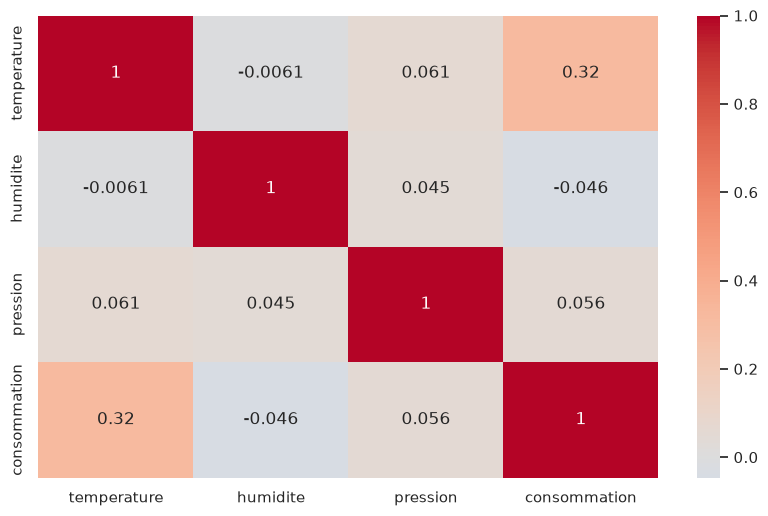

In [37]:
sns.heatmap(correlations, annot=True, cmap="coolwarm", center=0)
plt.show()

**Explication :**

**sns.heatmap()** transforme la matrice de chiffres en une grille de cases colorées, plus facile à lire d'un coup d'œil qu'un tableau de nombres

**annot=True** affiche la valeur numérique exacte dans chaque case, en plus de la couleur

**cmap="coolwarm"** choisit une palette de couleurs allant du bleu (froid) au rouge (chaud) — pratique ici pour distinguer visuellement corrélations négatives (bleu) et positives (rouge)

**center=0** force le point neutre de la palette de couleurs à être à 0 (ni positif ni négatif), pour que la lecture des couleurs soit symétrique et intuitive

#### a) les corrélations positives ;  

Seule température/consommation (0,32) ressort comme une vraie corrélation positive. Les autres paires positives (pression/consommation 0,06, pression/humidité 0,05, pression/température 0,06) sont trop faibles pour être significatives.

#### b) les corrélations négatives ; 

Deux paires sont négatives, mais très faibles : humidité/consommation (-0,05) et humidité/température (-0,006), trop proches de 0 pour indiquer une vraie relation inverse.

#### c) les corrélations proches de zéro ;

La majorité des paires sont proches de 0 : température/humidité, température/pression, humidité/pression, pression/consommation, humidité/consommation, aucune relation linéaire notable entre elles.

#### d) les variables qui semblent fortement liées.

Aucune paire n'est fortement corrélée dans ce dataset. La relation la plus marquée reste température/consommation (0,32), modérée mais pas forte. Toutes les autres variables semblent indépendantes entre elles.

## Partie 10 – Analyse multivariée avec pairplot()

**Objectif :** pairplot() il génère automatiquement toutes les combinaisons possibles de variables en une seule fois, distributions individuelles ET scatter plots croisés, dans une seule grille.

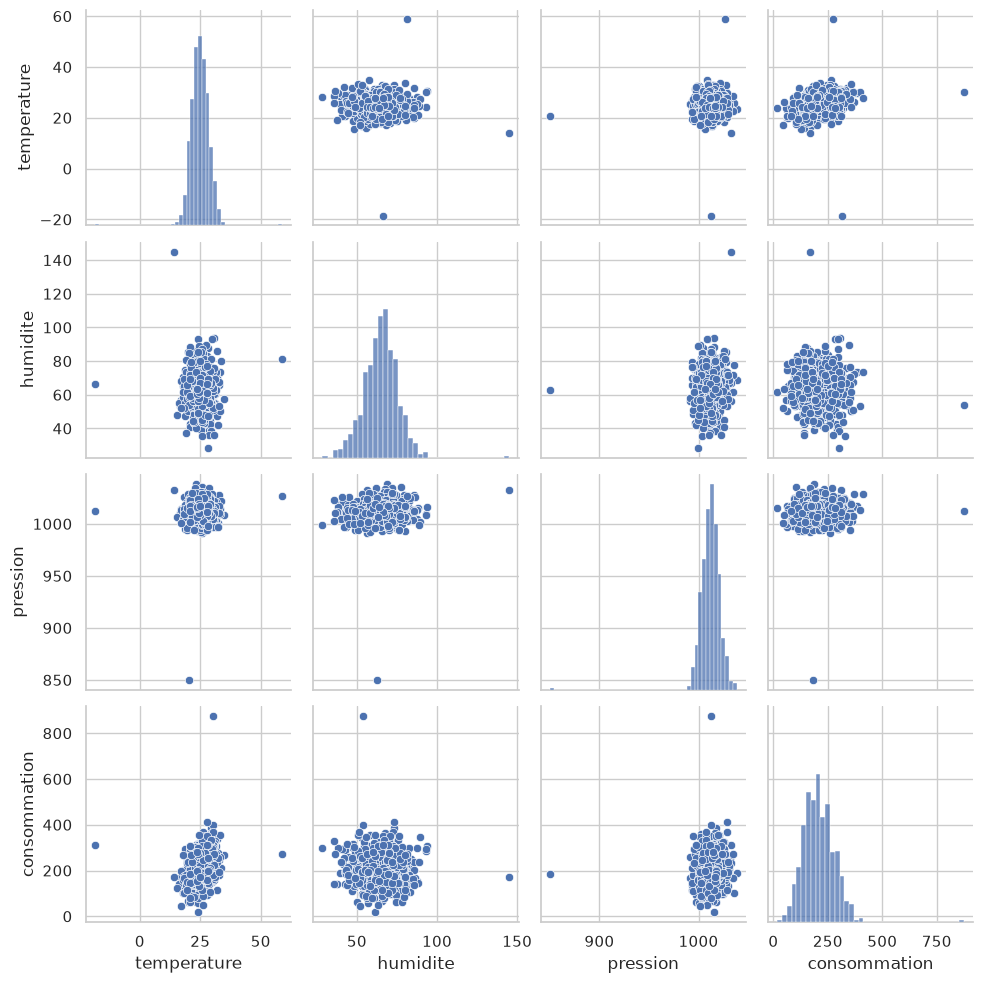

In [40]:
sns.pairplot(df[["temperature", "humidite", "pression", "consommation"]])
# on peut colorer par batiment en utilisant le hue 
#sns.pairplot(df[["temperature", "humidite", "pression", "consommation", "batiment"]], hue="batiment")
plt.show()

**Explication :**

On sélectionne les 4 colonnes numériques d'intérêt

**pairplot()** construit une grille N×N (ici 4×4, une ligne/colonne par variable)

**Sur la diagonale :** un histogramme (ou KDE) de la distribution de chaque variable seule, équivalent de ce qu'on a fait en Parties 1-2

**Hors diagonale :** un scatter plot entre chaque paire de variables, équivalent de ce qu'on a fait en Partie 6, mais pour toutes les combinaisons à la fois

C'est donc une façon très rapide d'avoir une vue d'ensemble complète du dataset, sans avoir à générer chaque graphique un par un.

la plupart des scatter plots se ressemblent : des nuages de points sans forme particulière, ce qui confirme l'absence de relation linéaire entre la majorité des paires de variables (comme vu avec les corrélations proches de 0 en Partie 9).

On observe cependant 2 à 4 points qui se détachent nettement du reste du nuage, sur plusieurs graphiques, ce sont très probablement les mêmes valeurs extrêmes/anomalies identifiées tout au long de l'atelier (notamment les capteurs en état ERREUR de B004, avec des températures de -18,50 °C et 58,70 °C). 

Comme ces mesures sont extrêmes sur plusieurs variables à la fois, elles apparaissent comme des points isolés sur plusieurs scatter plots du pairplot, pas seulement sur celui température/consommation.

## Partie 11 : Sauvegarde des graphiques

**Objectif :** Enregistrer les graphiques produits dans le dossier exports/, au format image, pour pouvoir les réutiliser en dehors du notebook (rapport, présentation, etc.).

**Principe général**

Pour n'importe quel graphique, il suffit d'ajouter plt.savefig(...) avant plt.show() (car plt.show() "vide" la figure en mémoire, si tu sauvegardes après, le fichier peut être vide).

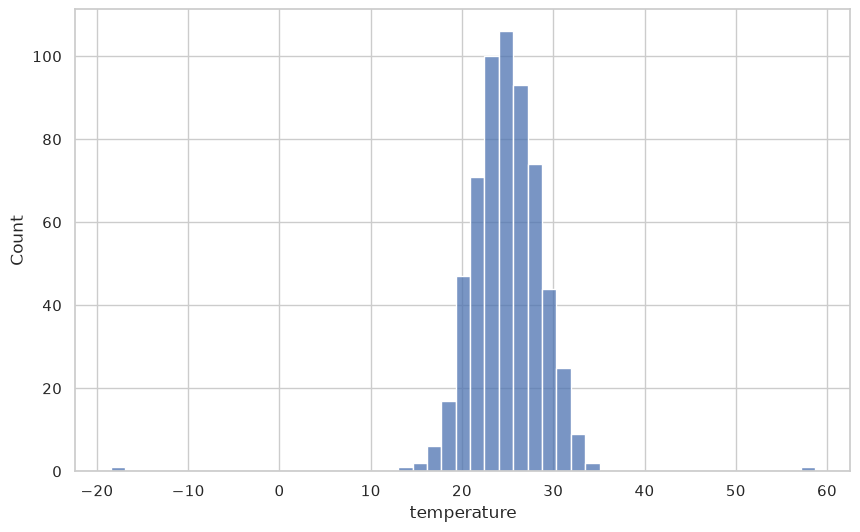

In [43]:
sns.histplot(data=df, x="temperature")
plt.savefig("../exports/temperature.png", dpi=300, bbox_inches="tight")
plt.savefig("../exports/temperature.pdf")
plt.show()

**Explication :**

plt.savefig("chemin/nom_fichier.extension") enregistre la figure actuellement en mémoire dans un fichier

Le chemin "../exports/..." suit la même logique que pour charger le CSV : on remonte d'un dossier depuis notebooks/ pour aller dans exports/

L'extension du fichier détermine le format : .png (image, le plus courant), .pdf (vectoriel, comme demandé dans l'énoncé), .svg, .jpg...

dpi=300 : augmente la résolution de l'image (utile si tu dois l'imprimer ou l'agrandir)

bbox_inches="tight" : évite que les bords du graphique (titres, légendes) soient coupés à l'export

## Partie 12 : Bonus

### Bonus 1 – Analyse temporelle

**Objectif :** Voir comment la température évolue dans le temps, avec date_heure.

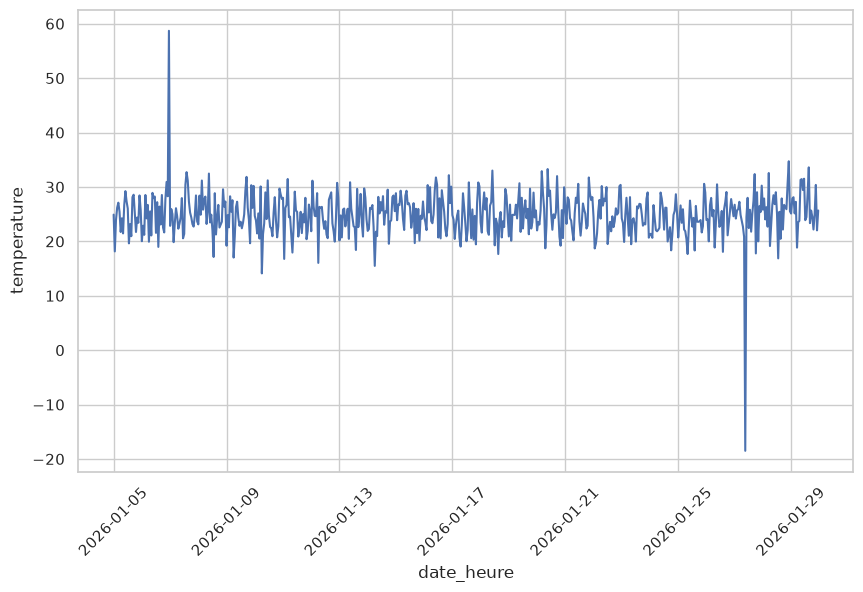

In [44]:
df["date_heure"] = pd.to_datetime(df["date_heure"])
df_sorted = df.sort_values("date_heure")

sns.lineplot(data=df_sorted, x="date_heure", y="temperature")
plt.xticks(rotation=45)
plt.show()

**Explication :**

pd.to_datetime() convertit la colonne date_heure (actuellement du texte) en vrai type date/heure, pour que pandas/seaborn puissent l'ordonner correctement sur l'axe X

.sort_values("date_heure") trie les données chronologiquement (important pour une courbe temporelle cohérente)

sns.lineplot() trace une ligne continue reliant les points dans l'ordre du temps, utile pour repérer des tendances ou cycles (ex: jour/nuit) plutôt qu'un nuage de points

On observe un pic marqué vers 60 °C entre le 5 et le 9 janvier, et un creux marqué (descente nette) entre le 25 et le 29 janvier. 

En dehors de ces deux événements ponctuels, la température oscille normalement entre 10 et 40 °C en zigzag, ce qui correspond à la variation naturelle jour/nuit déjà visible dans les histogrammes et KDE des premières parties.

### Bonus 2 – Détection automatique des capteurs à surveiller

**Objectif :** Identifier automatiquement, via le code, les capteurs qui cumulent le plus d'anomalies (ALERTE + ERREUR), sans avoir à le repérer manuellement graphique par graphique comme en Partie 5.

In [45]:
capteurs_anomalies = df[df["etat"].isin(["ALERTE", "ERREUR"])]
compte_par_capteur = capteurs_anomalies.groupby("id_capteur")["etat"].count().sort_values(ascending=False)
compte_par_capteur

id_capteur
C011    7
C010    6
C006    4
C012    4
C008    3
C003    2
C005    2
C007    2
C009    2
C004    1
C001    1
Name: etat, dtype: int64

**Explication :**

df["etat"].isin(["ALERTE", "ERREUR"]) filtre les lignes où l'état est anormal (exclut les OK)

.groupby("id_capteur")["etat"].count() compte, pour chaque capteur, le nombre de mesures anormales

.sort_values(ascending=False) trie du capteur le plus problématique au moins problématique

Le classement automatique confirme que C011 (7 anomalies) et C010 (6 anomalies) sont les capteurs les plus problématiques, suivis de C006 et C012 (4 chacun). 

Ces deux capteurs les plus en tête (C011, C010) appartiennent tous les deux à B004, ce qui confirme une nouvelle fois que ce bâtiment concentre la majorité des dysfonctionnements de capteurs observés dans l'atelier.

On note aussi que C001 n'a qu'1 seule anomalie sur toute la période, c'est donc le capteur le plus fiable du parc.

In [46]:
df[df["id_capteur"].isin(["C011", "C010"])]["batiment"].unique()

<StringArray>
['B004']
Length: 1, dtype: str

C011 et C010, les deux capteurs les plus problématiques (7 et 6 anomalies), appartiennent tous les deux exclusivement à B004, ce qui confirme définitivement que les dysfonctionnements observés dans l'atelier ne sont pas répartis au hasard, mais concentrés sur ce bâtiment en particulier. Une action de maintenance ciblée sur B004, et plus précisément sur les capteurs C010 et C011, serait donc la priorité.

### Bonus 3 – Nettoyage des valeurs manquantes

**Objectif :** On avait détecté en tout début d'atelier (df.isna().sum()) des valeurs manquantes sur plusieurs colonnes (temperature: 6, humidite: 5, pression: 5, consommation: 5, etat: 4). Ici, on propose et applique une vraie stratégie pour les traiter, plutôt que de les laisser telles quelles.

In [47]:
df.isna().sum()

id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     6
humidite        5
pression        5
consommation    5
etat            4
dtype: int64

In [48]:
for col in ["temperature", "humidite", "pression", "consommation"]:
    df[col] = df[col].fillna(df[col].median())

df["etat"] = df["etat"].fillna("INCONNU")

In [49]:
df.isna().sum()

id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     0
humidite        0
pression        0
consommation    0
etat            0
dtype: int64

Après application de la stratégie de nettoyage (médiane pour les colonnes numériques, catégorie "INCONNU" pour etat), le dataset ne contient plus aucune valeur manquante : les 605 mesures sont désormais complètes sur toutes les colonnes.

### Bonus 4 – Export d'un rapport de synthèse

**Objectif :** Regrouper les principales conclusions de l'atelier dans un fichier texte lisible, sans avoir à rouvrir le notebook.

In [50]:
rapport = f"""RAPPORT DE SYNTHESE - ATELIER SEABORN IOT
==========================================

1. TEMPERATURE
   - Moyenne : {df['temperature'].mean():.2f} °C, Médiane : {df['temperature'].median():.2f} °C
   - Distribution asymétrique (skew = -1.05), traîne vers les valeurs basses
   - 5 valeurs extrêmes détectées (méthode IQR)

2. BATIMENTS
   - Médianes proches (B003: 23.05 à B004: 27.54)
   - B004 nettement plus dispersé (écart-type 5.37 vs ~3 pour les autres)
   - B004 a les valeurs les plus extrêmes (-18.50 °C à 58.70 °C)

3. ETATS DES CAPTEURS
   - B004 concentre le plus d'ALERTE (15) et d'ERREUR (2 ex-aequo avec B003)
   - Capteurs les plus problématiques : C011 (7 anomalies), C010 (6 anomalies), tous deux à B004

4. CORRELATIONS
   - Seule relation notable : température/consommation (r = 0.32), positive mais modérée
   - Toutes les autres paires de variables sont quasi indépendantes (r proche de 0)
   - La corrélation par bâtiment est plus faible que la corrélation globale

5. RECOMMANDATION
   - Prioriser la maintenance du bâtiment B004, en particulier les capteurs C010 et C011
"""

with open("../exports/rapport_synthese.txt", "w", encoding="utf-8") as f:
    f.write(rapport)

print(rapport)

RAPPORT DE SYNTHESE - ATELIER SEABORN IOT

1. TEMPERATURE
   - Moyenne : 24.88 °C, Médiane : 24.86 °C
   - Distribution asymétrique (skew = -1.05), traîne vers les valeurs basses
   - 5 valeurs extrêmes détectées (méthode IQR)

2. BATIMENTS
   - Médianes proches (B003: 23.05 à B004: 27.54)
   - B004 nettement plus dispersé (écart-type 5.37 vs ~3 pour les autres)
   - B004 a les valeurs les plus extrêmes (-18.50 °C à 58.70 °C)

3. ETATS DES CAPTEURS
   - B004 concentre le plus d'ALERTE (15) et d'ERREUR (2 ex-aequo avec B003)
   - Capteurs les plus problématiques : C011 (7 anomalies), C010 (6 anomalies), tous deux à B004

4. CORRELATIONS
   - Seule relation notable : température/consommation (r = 0.32), positive mais modérée
   - Toutes les autres paires de variables sont quasi indépendantes (r proche de 0)
   - La corrélation par bâtiment est plus faible que la corrélation globale

5. RECOMMANDATION
   - Prioriser la maintenance du bâtiment B004, en particulier les capteurs C010 et C011

**Explication :**

Une f-string (f"""...""") permet d'insérer directement des valeurs calculées (comme df['temperature'].mean()) dans le texte

open(..., "w", encoding="utf-8") ouvre (ou crée) un fichier en écriture, f.write(rapport) y écrit le texte

Le fichier est sauvegardé dans exports/, comme les graphiques de la Partie 11

### Bonus 5 – Facettes avec FacetGrid

**Objectif :** Croiser deux variables catégorielles en même temps (par exemple bâtiment ET état), en générant automatiquement une grille de sous-graphiques, un par combinaison.

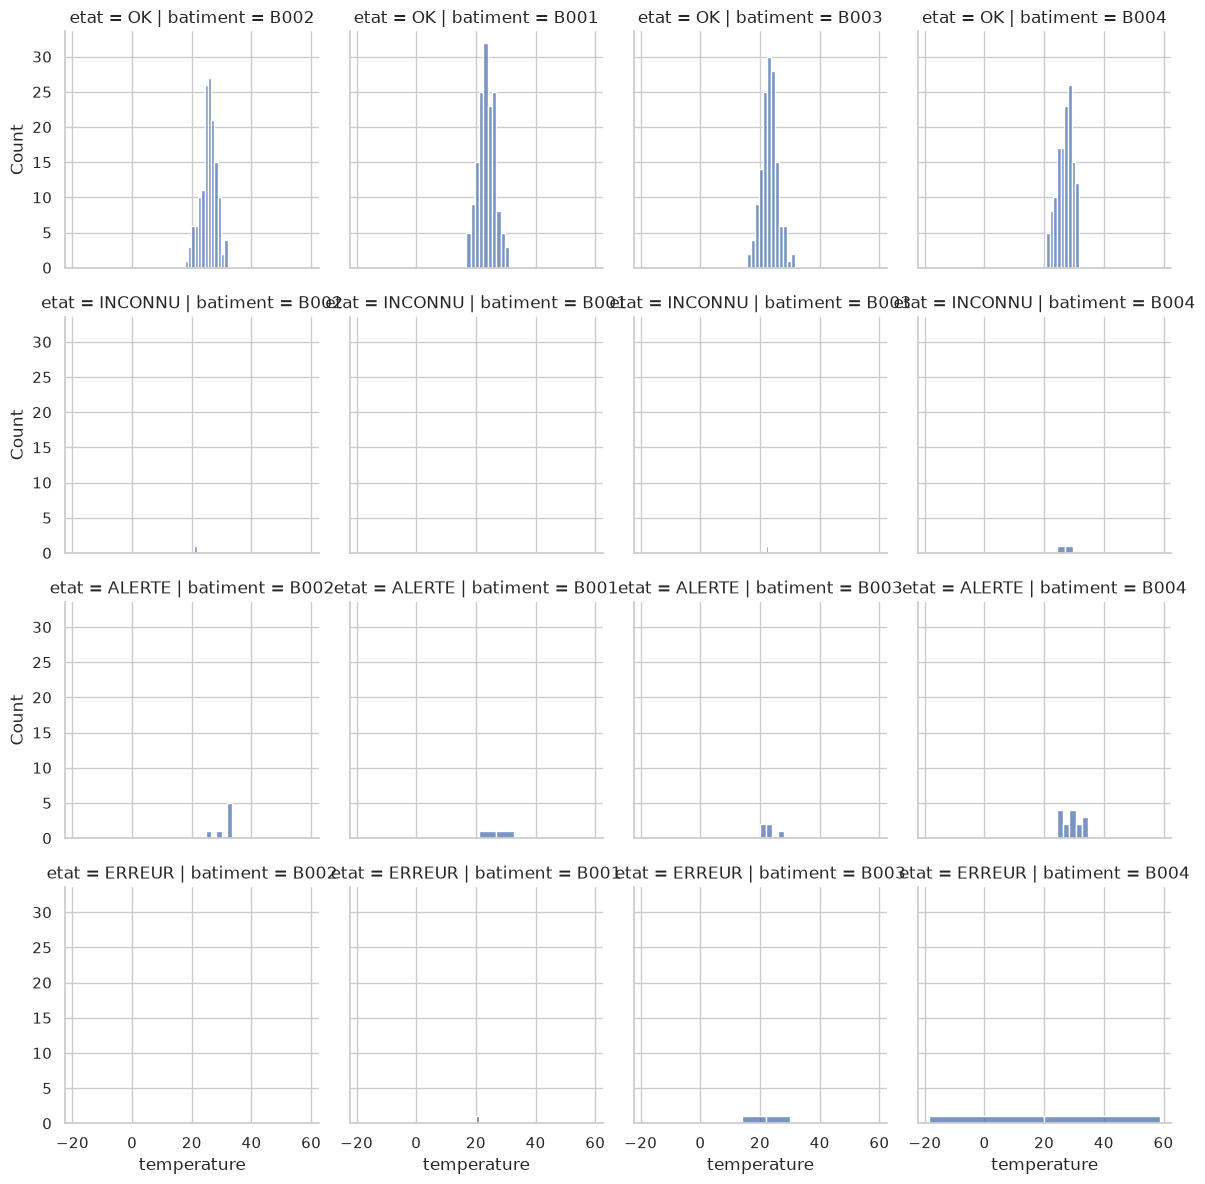

In [51]:
g = sns.FacetGrid(df, col="batiment", row="etat", height=3)
g.map(sns.histplot, "temperature")
plt.show()

**Explication :**

sns.FacetGrid(df, col="batiment", row="etat") prépare une grille : une colonne par bâtiment (4 colonnes) et une ligne par état (OK, ALERTE, ERREUR, INCONNU → jusqu'à 4 lignes). 

Ça crée jusqu'à 16 petites cases, une pour chaque combinaison bâtiment × état.

height=3 fixe la taille de chaque sous-graphique (sinon la grille peut être énorme ou minuscule)

g.map(sns.histplot, "temperature") applique un histogramme de température dans chaque case de la grille

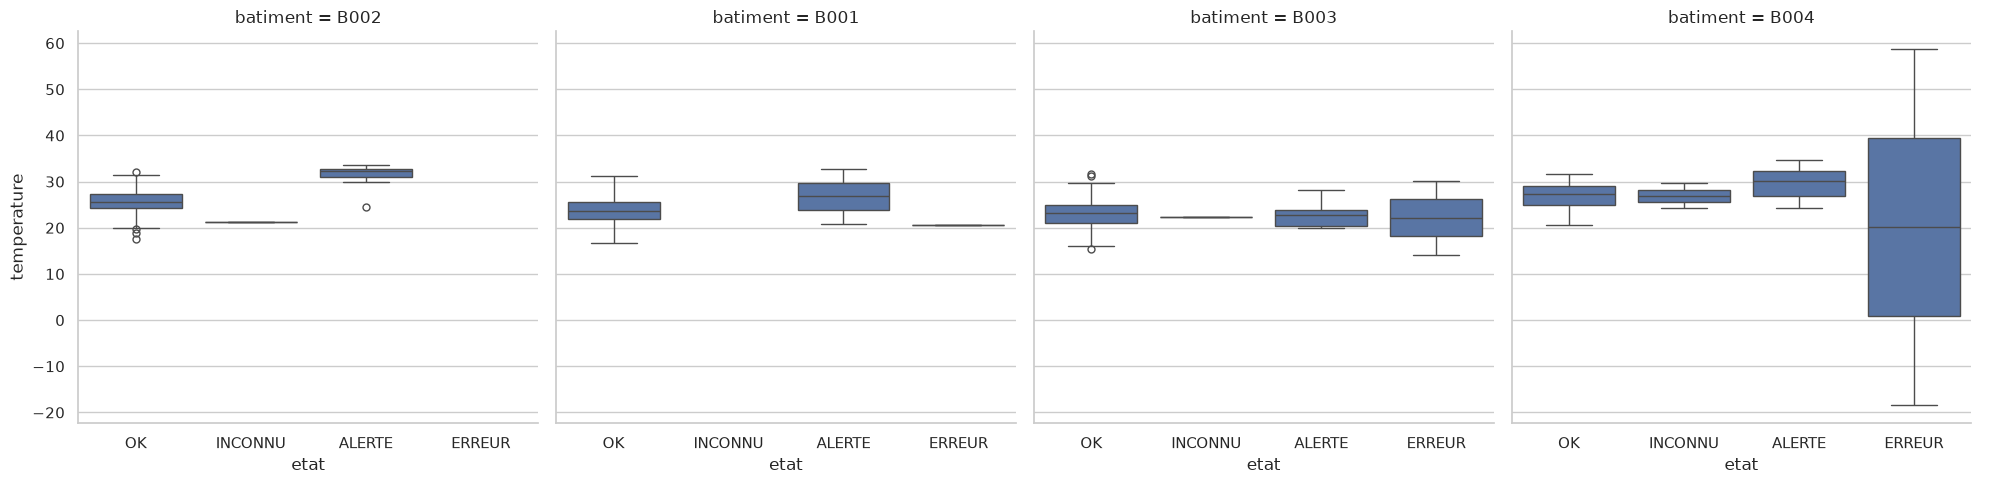

In [52]:
sns.catplot(data=df, x="etat", y="temperature", col="batiment", kind="box")
plt.show()

catplot(kind="box") reproduit un boxplot température/état, mais répété une fois par bâtiment (grâce à col="batiment"), plus lisible qu'un FacetGrid complet 4×4 avec peu de données dans certaines cases.

In [53]:
pd.crosstab(df["batiment"], df["etat"])

etat,ALERTE,ERREUR,INCONNU,OK
batiment,,,,
B001,2,1,0,150
B002,7,0,1,142
B003,5,2,1,142
B004,15,2,2,133


Avec le FacetGrid (grille bâtiment × état), deux combinaisons sont vides : B001 × INCONNU et B002 × ERREUR, car aucune mesure ne correspond à ces croisements dans le dataset.

Avec le catplot (un sous-graphique par bâtiment), cela se traduit par une boîte manquante sur certains bâtiments : B001 n'affiche pas de boîte INCONNU, et B002 n'affiche pas de boîte ERREUR, les deux autres bâtiments (B003, B004) affichent bien leurs 4 boîtes, puisqu'ils ont au moins une mesure dans chacun des 4 états.